
# TVP-VAR connectedness для 5 фондовых индексов

Этот ноутбук строит **TVP-VAR** для пяти фондовых индексов:

- **S&P 500** (`SPX Index`)
- **FTSE 100** (`UKX Index`)
- **Nikkei 225** (`NKY Index`)
- **Hang Seng** (`HSI Index`)
- **NIFTY 50** (`NIFTY Index`)

## Что проверяем

**H5.** Рынок США (S&P 500) выступает нетто-передатчиком шоков для других рассматриваемых рынков.  
**H6.** В периоды глобального финансового стресса общая связанность рынков возрастает, а роль S&P 500 как передатчика шоков усиливается.

## Что делает ноутбук

1. Загружает и очищает данные из `data.xlsx`.
2. Строит **monthly log-returns** пяти индексов.
3. Оценивает **TVP-VAR(1)** в форме time-varying parameter regression с forgetting factors.
4. Строит **generalized FEVD** и connectedness-метрики:
   - **TCI** (Total Connectedness Index)
   - **Directional TO**
   - **Directional FROM**
   - **NET connectedness**
   - **Net pairwise directional connectedness** для S&P 500 против остальных рынков
5. Сохраняет графики и таблицы в папку `tvp_var_outputs`.



In [8]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

DATA_PATH = Path("data/data.xlsx")
OUTPUT_DIR = Path("tvp_var_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

INDEX_MAP = {
    "SPX Index": "S&P 500",
    "UKX Index": "FTSE 100",
    "NKY Index": "Nikkei 225",
    "HSI Index": "Hang Seng",
    "NIFTY Index": "NIFTY 50",
}

INDEX_COLS = list(INDEX_MAP.keys())

## 1. Вспомогательные функции

In [ ]:
def load_index_data(path: Path, cols: list[str]) -> pd.DataFrame:
    df = pd.read_excel(path, sheet_name="static", parse_dates=["Dates"])
    df = df[["Dates"] + cols].dropna(subset=["Dates"]).sort_values("Dates")
    df = df.set_index("Dates")
    return df

def to_monthly_returns(price_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    monthly_prices = price_df.resample("ME").last().dropna(how="all")
    monthly_prices = monthly_prices.ffill(limit=1)
    monthly_prices = monthly_prices.dropna(how="any")
    monthly_log_returns = np.log(monthly_prices).diff().dropna()
    return monthly_prices, monthly_log_returns

def adf_table(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for col in df.columns:
        stat, pvalue, _, _, crit, _ = adfuller(df[col].dropna(), autolag="AIC")
        rows.append({
            "series": col,
            "adf_stat": stat,
            "p_value": pvalue,
            "crit_1%": crit["1%"],
            "crit_5%": crit["5%"],
            "crit_10%": crit["10%"],
        })
    out = pd.DataFrame(rows).set_index("series")
    return out

def lag_selection_info(df: pd.DataFrame, maxlags: int = 6) -> pd.Series:
    sel = VAR(df).select_order(maxlags=maxlags)
    out = pd.Series({
        "AIC": sel.aic,
        "BIC": sel.bic,
        "HQIC": sel.hqic,
        "FPE": sel.fpe,
    })
    return out

def build_lagged_design(y: pd.DataFrame, p: int = 1):
    yv = y.values
    T, k = yv.shape
    X, Y, dates = [], [], []
    for t in range(p, T):
        x = [1.0]
        for lag in range(1, p + 1):
            x.extend(yv[t - lag])
        X.append(x)
        Y.append(yv[t])
        dates.append(y.index[t])
    return np.array(Y), np.array(X), pd.Index(dates), list(y.columns)

def fit_tvp_var_discount(
    y: pd.DataFrame,
    p: int = 1,
    lambda_beta: float = 0.99,
    kappa_sigma: float = 0.96,
    init_var: float = 0.05,
):
    """
    Equation-by-equation TVP-VAR with random-walk coefficients and discount factors.

    y_{i,t} = x_t' beta_{i,t} + e_{i,t}
    beta_{i,t} = beta_{i,t-1} + eta_{i,t}

    lambda_beta controls coefficient drift (higher = smoother coefficients).
    kappa_sigma controls exponential smoothing of residual covariance.
    """
    Y, X, dates, names = build_lagged_design(y, p)
    T, k = Y.shape
    m = X.shape[1]

    betas = np.zeros((T, k, m))
    residuals = np.zeros((T, k))
    sigmas = np.zeros((T, k, k))

    beta_prev = np.zeros((k, m))
    P_prev = np.array([np.eye(m) * init_var for _ in range(k)])

    base_var = np.var(Y[: min(60, T)], axis=0, ddof=1)
    base_var = np.where(np.isfinite(base_var) & (base_var > 1e-8), base_var, 1e-4)
    R = base_var.copy()
    Sigma_prev = np.diag(R)

    for t in range(T):
        x = X[t]
        errs = np.zeros(k)
        beta_t = np.zeros((k, m))
        P_t = np.zeros((k, m, m))

        for i in range(k):
            beta_pred = beta_prev[i]
            P_pred = P_prev[i] / lambda_beta

            yhat = x @ beta_pred
            S = x @ P_pred @ x + R[i]
            K = (P_pred @ x) / S

            err = Y[t, i] - yhat
            beta_upd = beta_pred + K * err
            P_upd = P_pred - np.outer(K, x) @ P_pred
            P_upd = (P_upd + P_upd.T) / 2

            beta_t[i] = beta_upd
            P_t[i] = P_upd
            errs[i] = err

        outer = np.outer(errs, errs)
        Sigma_t = kappa_sigma * Sigma_prev + (1 - kappa_sigma) * outer
        Sigma_t = (Sigma_t + Sigma_t.T) / 2

        eigvals = np.linalg.eigvalsh(Sigma_t)
        if eigvals.min() <= 1e-10:
            Sigma_t += np.eye(k) * (1e-8 - eigvals.min())

        R = np.diag(Sigma_t).copy()
        R = np.where(R > 1e-8, R, 1e-8)

        betas[t] = beta_t
        residuals[t] = errs
        sigmas[t] = Sigma_t

        beta_prev = beta_t
        P_prev = P_t
        Sigma_prev = Sigma_t

    return {
        "betas": betas,
        "sigmas": sigmas,
        "residuals": residuals,
        "dates": dates,
        "names": names,
        "p": p,
        "lambda_beta": lambda_beta,
        "kappa_sigma": kappa_sigma,
    }

def extract_A_matrices(beta_t: np.ndarray, k: int, p: int):
    A = []
    offset = 1  # constant is first
    for lag in range(p):
        block = beta_t[:, offset + lag * k : offset + (lag + 1) * k]
        A.append(block)
    return A

def generalized_fevd(A_mats, Sigma, H: int = 10) -> np.ndarray:
    """
    Generalized Forecast Error Variance Decomposition (Pesaran-Shin style).
    Returns row-normalized FEVD matrix.
    """
    k = Sigma.shape[0]
    p = len(A_mats)

    Phi = [np.eye(k)]
    for h in range(1, H):
        phi_h = np.zeros((k, k))
        for lag in range(1, min(p, h) + 1):
            phi_h += Phi[h - lag] @ A_mats[lag - 1]
        Phi.append(phi_h)

    sigma_diag = np.diag(Sigma).copy()
    sigma_diag = np.where(sigma_diag > 1e-12, sigma_diag, 1e-12)

    fevd = np.zeros((k, k))
    for i in range(k):
        e_i = np.zeros(k)
        e_i[i] = 1.0

        denom = 0.0
        num = np.zeros(k)

        for h in range(H):
            term = e_i @ Phi[h] @ Sigma
            denom += e_i @ Phi[h] @ Sigma @ Phi[h].T @ e_i
            num += (term ** 2) / sigma_diag

        fevd[i, :] = num / max(denom, 1e-12)

    row_sums = fevd.sum(axis=1, keepdims=True)
    fevd_norm = fevd / np.where(row_sums == 0, 1, row_sums)
    return fevd_norm

def compute_connectedness(fit: dict, H: int = 10):
    betas = fit["betas"]
    sigmas = fit["sigmas"]
    dates = fit["dates"]
    names = fit["names"]
    p = fit["p"]

    T, k, _ = betas.shape
    fevds = np.zeros((T, k, k))
    tci = np.zeros(T)
    to_others = np.zeros((T, k))
    from_others = np.zeros((T, k))
    net = np.zeros((T, k))
    pairwise = np.zeros((T, k, k))

    for t in range(T):
        A_mats = extract_A_matrices(betas[t], k, p)
        fevd = generalized_fevd(A_mats, sigmas[t], H=H)
        fevds[t] = fevd

        offdiag_sum = fevd.sum() - np.trace(fevd)
        tci[t] = 100 * offdiag_sum / k

        from_others[t] = 100 * (fevd.sum(axis=1) - np.diag(fevd))
        to_others[t] = 100 * (fevd.sum(axis=0) - np.diag(fevd))
        net[t] = to_others[t] - from_others[t]

        for i in range(k):
            for j in range(k):
                if i != j:
                    pairwise[t, i, j] = 100 * (fevd[j, i] - fevd[i, j])

    npdc_dict = {}
    for i in range(k):
        for j in range(i + 1, k):
            npdc_dict[(names[i], names[j])] = pd.Series(pairwise[:, i, j], index=dates)

    return {
        "dates": dates,
        "names": names,
        "FEVD": fevds,
        "TCI": pd.Series(tci, index=dates, name="TCI"),
        "TO": pd.DataFrame(to_others, index=dates, columns=names),
        "FROM": pd.DataFrame(from_others, index=dates, columns=names),
        "NET": pd.DataFrame(net, index=dates, columns=names),
        "NPDC": npdc_dict,
    }

def pretty_name(col: str) -> str:
    return INDEX_MAP.get(col, col)

def rename_columns(df: pd.DataFrame) -> pd.DataFrame:
    return df.rename(columns=INDEX_MAP)

def add_crisis_spans(ax):
    spans = [
        ("1997-07-01", "1998-12-31", "Asian crisis"),
        ("2008-09-01", "2009-06-30", "Global financial crisis"),
        ("2020-02-01", "2020-06-30", "COVID shock"),
        ("2022-02-01", "2023-01-31", "Inflation / rate shock"),
    ]
    for start, end, _ in spans:
        ax.axvspan(pd.to_datetime(start), pd.to_datetime(end), alpha=0.12)
    return ax

## 2. Загрузка данных и построение monthly returns

In [ ]:
prices_daily = load_index_data(DATA_PATH, INDEX_COLS)
prices_monthly, returns_monthly = to_monthly_returns(prices_daily)

print("Диапазон ежедневных цен:", prices_daily.index.min().date(), "—", prices_daily.index.max().date())
print("Диапазон monthly цен:", prices_monthly.index.min().date(), "—", prices_monthly.index.max().date())
print("Диапазон monthly returns:", returns_monthly.index.min().date(), "—", returns_monthly.index.max().date())
print("Размерность выборки returns:", returns_monthly.shape)

returns_monthly.head()

Диапазон ежедневных цен: 1985-01-23 — 2025-01-23
Диапазон monthly цен: 1990-07-31 — 2025-01-31
Диапазон monthly returns: 1990-08-31 — 2025-01-31
Размерность выборки returns: (414, 5)


,SPX Index,UKX Index,NKY Index,HSI Index,NIFTY Index
Dates,,,,,
1990-08-31,-0.099063,-0.072832,-0.177873,-0.107671,0.141023
1990-09-30,-0.052541,-0.083118,-0.213528,-0.111834,0.094524
1990-10-31,-0.006721,0.029701,0.182873,0.080067,-0.085565
1990-11-30,0.058207,0.047156,-0.115113,-0.008697,-0.093333
1990-12-31,0.024525,-0.002749,0.060233,0.019865,-0.105545


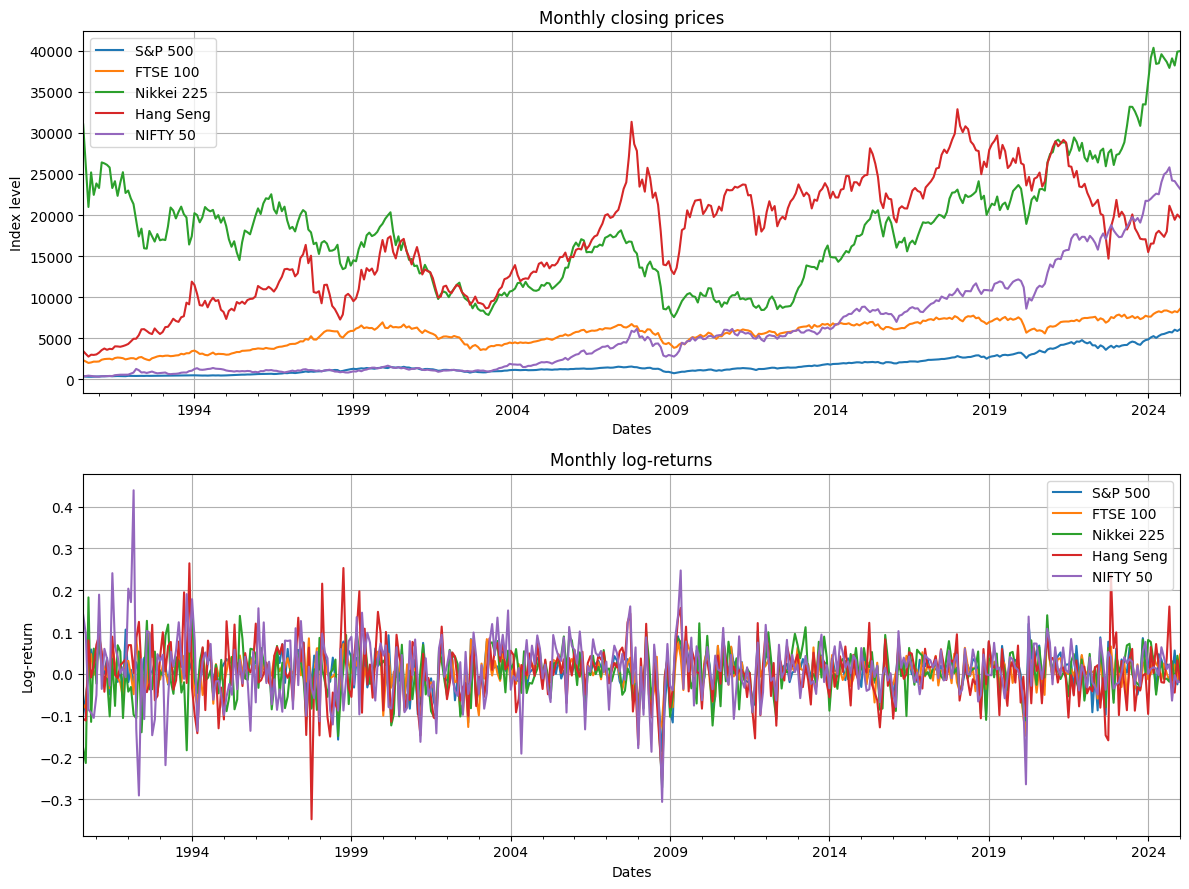

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=False)

rename_columns(prices_monthly).plot(ax=axes[0], title="Monthly closing prices")
rename_columns(returns_monthly).plot(ax=axes[1], title="Monthly log-returns")

axes[0].set_ylabel("Index level")
axes[1].set_ylabel("Log-return")
plt.tight_layout()

fig.savefig(OUTPUT_DIR / "01_prices_and_returns.png", dpi=200, bbox_inches="tight")
plt.show()

## 3. Проверка стационарности returns и выбор лага

In [ ]:
adf_results = adf_table(returns_monthly)
adf_results

,adf_stat,p_value,crit_1%,crit_5%,crit_10%
series,,,,,
SPX Index,-20.409142,0.0,-3.446283,-2.868564,-2.570511
UKX Index,-20.109784,0.0,-3.446283,-2.868564,-2.570511
NKY Index,-19.838007,0.0,-3.446283,-2.868564,-2.570511
HSI Index,-19.794088,0.0,-3.446283,-2.868564,-2.570511
NIFTY Index,-19.433866,0.0,-3.446283,-2.868564,-2.570511


In [ ]:
lag_info = lag_selection_info(returns_monthly, maxlags=6)
lag_info

AIC     0
BIC     0
HQIC    0
FPE     0
dtype: int64


Для TVP-VAR в этом ноутбуке используется **один лаг**:

- monthly returns уже достаточно “короткие” по памяти;
- при 5 переменных и time-varying коэффициентах спецификация с большим числом лагов быстро раздувает число параметров;
- VAR(1) даёт более устойчивую TVP-VAR-connectedness оценку на этой выборке.


In [ ]:
P_LAGS = 1
LAMBDA_BETA = 0.99   # чем ближе к 1, тем плавнее эволюция коэффициентов
KAPPA_SIGMA = 0.96   # сглаживание ковариационной матрицы ошибок
HORIZON = 10         # горизонт FEVD в месяцах

print(f"P_LAGS={P_LAGS}, LAMBDA_BETA={LAMBDA_BETA}, KAPPA_SIGMA={KAPPA_SIGMA}, HORIZON={HORIZON}")

P_LAGS=1, LAMBDA_BETA=0.99, KAPPA_SIGMA=0.96, HORIZON=10


## 4. Оценивание TVP-VAR

In [ ]:
tvp_fit = fit_tvp_var_discount(
    returns_monthly,
    p=P_LAGS,
    lambda_beta=LAMBDA_BETA,
    kappa_sigma=KAPPA_SIGMA,
    init_var=0.05,
)

connectedness = compute_connectedness(tvp_fit, H=HORIZON)

print("TVP-VAR оценён.")
print("Количество временных точек после учёта лагов:", len(connectedness["TCI"]))

TVP-VAR оценён.
Количество временных точек после учёта лагов: 413


## 5. Основные connectedness-метрики

In [ ]:
tci = connectedness["TCI"]
to_df = rename_columns(connectedness["TO"])
from_df = rename_columns(connectedness["FROM"])
net_df = rename_columns(connectedness["NET"])

summary_table = pd.DataFrame({
    "Average TO": to_df.mean(),
    "Average FROM": from_df.mean(),
    "Average NET": net_df.mean(),
}).sort_values("Average NET", ascending=False)

summary_table

,Average TO,Average FROM,Average NET
S&P 500,62.957380,56.782161,6.175218
FTSE 100,57.808689,54.728121,3.080568
Hang Seng,49.925446,48.994613,0.930834
Nikkei 225,40.289501,44.950150,-4.660649
NIFTY 50,33.598446,39.124417,-5.525971


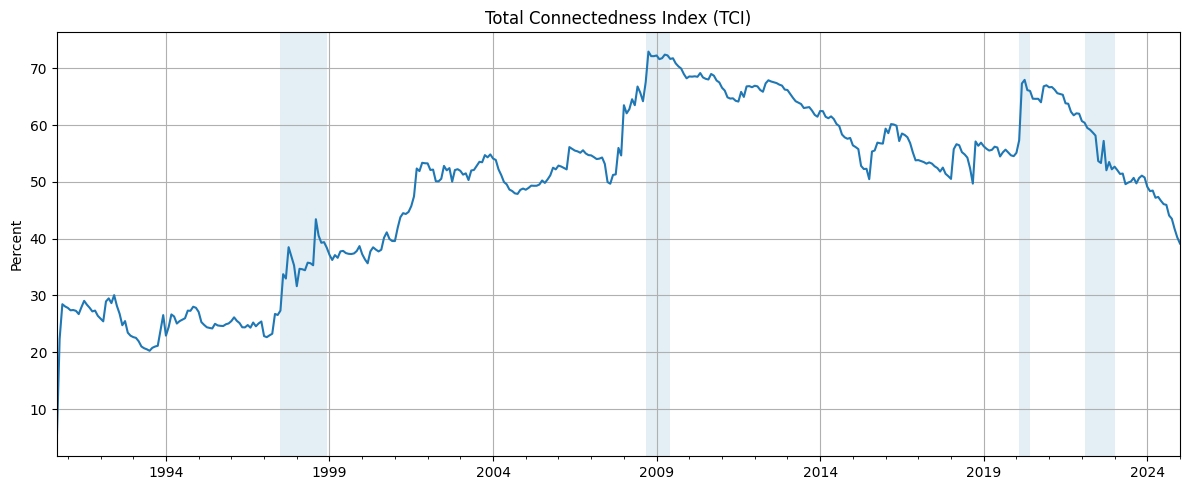

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
tci.plot(ax=ax, title="Total Connectedness Index (TCI)")
add_crisis_spans(ax)
ax.set_ylabel("Percent")
plt.tight_layout()

fig.savefig(OUTPUT_DIR / "02_tci.png", dpi=200, bbox_inches="tight")
plt.show()

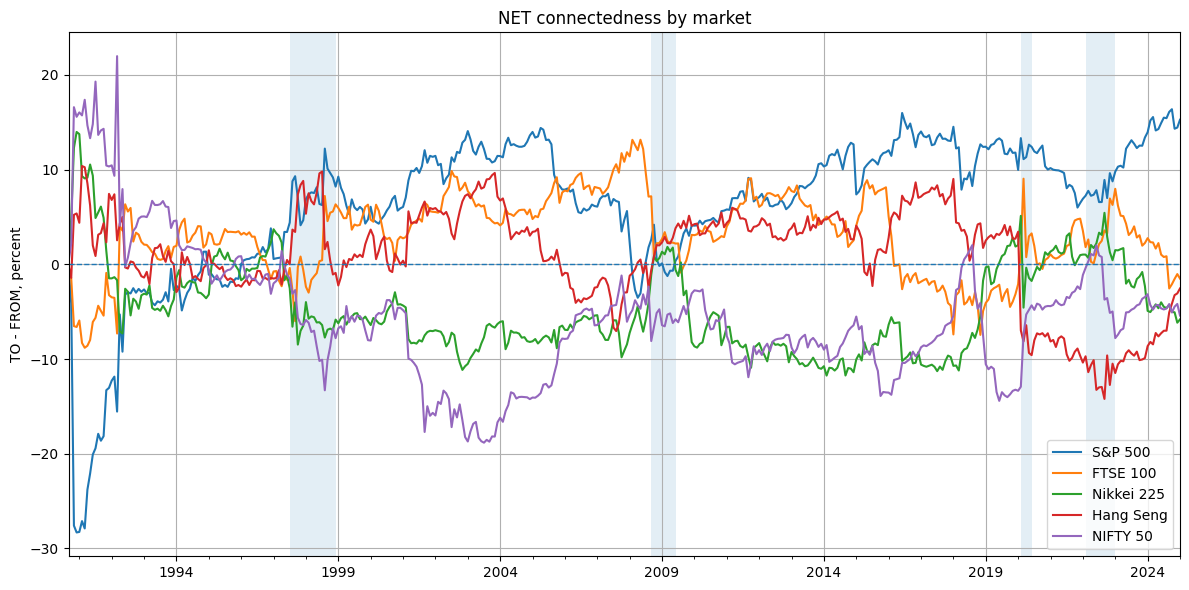

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
net_df.plot(ax=ax, title="NET connectedness by market")
add_crisis_spans(ax)
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_ylabel("TO - FROM, percent")
plt.tight_layout()

fig.savefig(OUTPUT_DIR / "03_net_connectedness_all.png", dpi=200, bbox_inches="tight")
plt.show()

## 6. Фокус на S&P 500

In [ ]:
spx_focus = pd.DataFrame({
    "TO others": to_df["S&P 500"],
    "FROM others": from_df["S&P 500"],
    "NET": net_df["S&P 500"],
})

spx_focus.tail()

,TO others,FROM others,NET
2024-09-30,73.362250,57.266222,16.096028
2024-10-31,73.135563,56.755136,16.380427
2024-11-30,68.745527,54.428230,14.317297
2024-12-31,68.039798,53.597546,14.442252
2025-01-31,68.396739,53.128598,15.268142


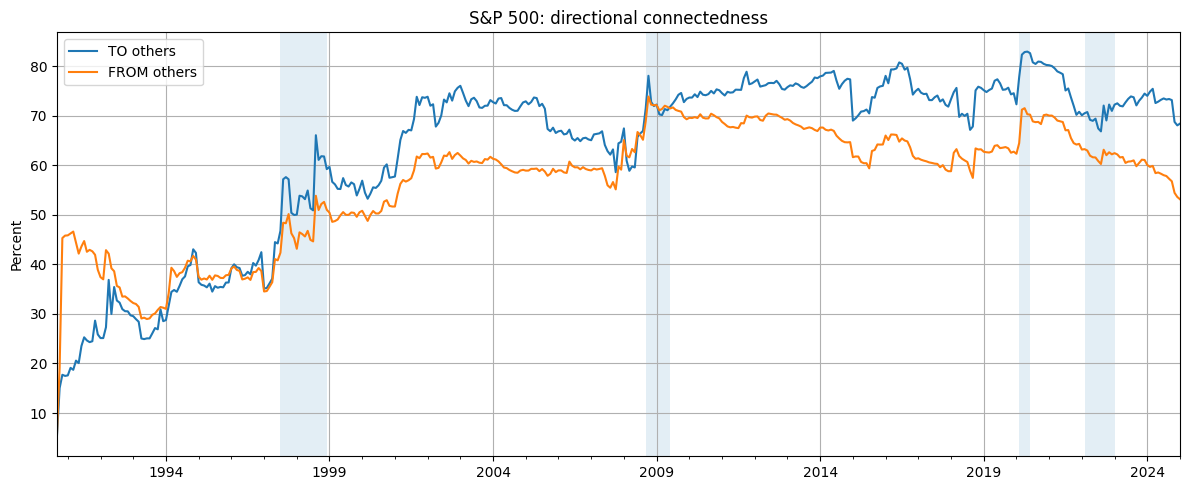

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
spx_focus[["TO others", "FROM others"]].plot(ax=ax, title="S&P 500: directional connectedness")
add_crisis_spans(ax)
ax.set_ylabel("Percent")
plt.tight_layout()

fig.savefig(OUTPUT_DIR / "04_spx_to_from.png", dpi=200, bbox_inches="tight")
plt.show()

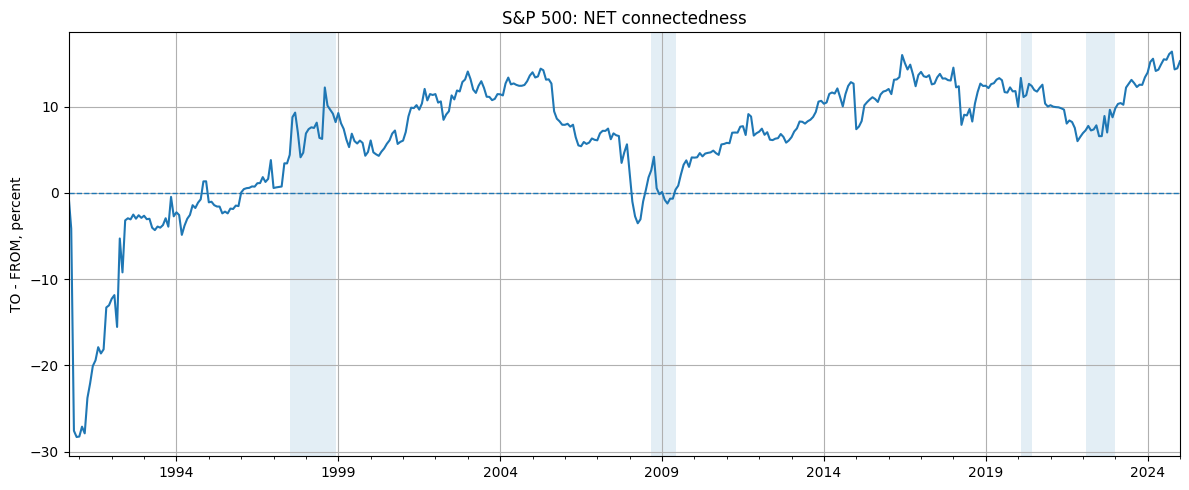

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
spx_focus["NET"].plot(ax=ax, title="S&P 500: NET connectedness")
add_crisis_spans(ax)
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_ylabel("TO - FROM, percent")
plt.tight_layout()

fig.savefig(OUTPUT_DIR / "05_spx_net.png", dpi=200, bbox_inches="tight")
plt.show()

## 7. Парные связи S&P 500 с остальными рынками

In [ ]:
pairwise_spx = {}
for (a, b), s in connectedness["NPDC"].items():
    a_name, b_name = pretty_name(a), pretty_name(b)
    if a == "SPX Index" or b == "SPX Index":
        series_name = f"{a_name} vs {b_name}"
        pairwise_spx[series_name] = s

pairwise_spx_df = pd.DataFrame(pairwise_spx)
pairwise_spx_df.head()

,S&P 500 vs FTSE 100,S&P 500 vs Nikkei 225,S&P 500 vs Hang Seng,S&P 500 vs NIFTY 50
1990-09-30,-0.013715,-0.132439,-0.012538,-0.059504
1990-10-31,-0.374969,-1.447159,-0.133794,-2.190140
1990-11-30,-1.444713,-9.632129,-4.781583,-11.731211
1990-12-31,-1.140691,-10.086916,-4.895995,-12.187975
1991-01-31,-1.051062,-10.140599,-4.758614,-12.305727


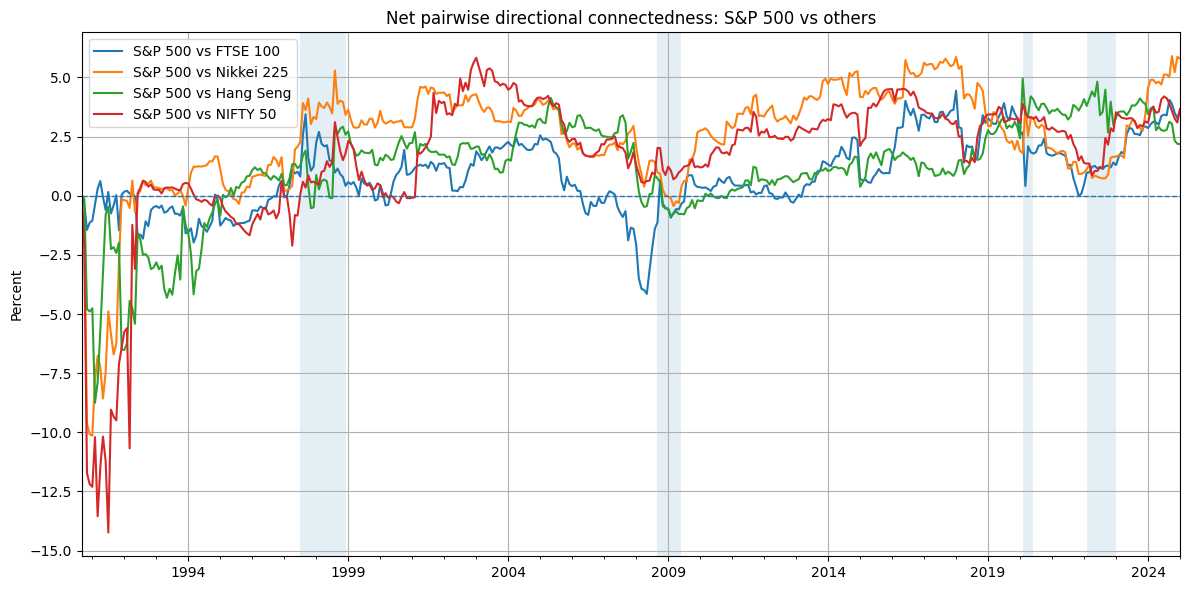

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
pairwise_spx_df.plot(ax=ax, title="Net pairwise directional connectedness: S&P 500 vs others")
add_crisis_spans(ax)
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_ylabel("Percent")
plt.tight_layout()

fig.savefig(OUTPUT_DIR / "06_spx_pairwise.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
pairwise_avg = pairwise_spx_df.mean().sort_values(ascending=False).to_frame("Average NPDC")
pairwise_avg

,Average NPDC
S&P 500 vs Nikkei 225,2.480504
S&P 500 vs NIFTY 50,1.643030
S&P 500 vs Hang Seng,1.162876
S&P 500 vs FTSE 100,0.888808


## 8. Сохранение результатов

In [ ]:
rename_columns(prices_monthly).to_csv(OUTPUT_DIR / "monthly_prices.csv")
rename_columns(returns_monthly).to_csv(OUTPUT_DIR / "monthly_log_returns.csv")
tci.to_csv(OUTPUT_DIR / "tci_series.csv")
to_df.to_csv(OUTPUT_DIR / "directional_to.csv")
from_df.to_csv(OUTPUT_DIR / "directional_from.csv")
net_df.to_csv(OUTPUT_DIR / "net_connectedness.csv")
summary_table.to_csv(OUTPUT_DIR / "summary_connectedness_table.csv")
pairwise_spx_df.to_csv(OUTPUT_DIR / "spx_pairwise_npdc_series.csv")
pairwise_avg.to_csv(OUTPUT_DIR / "spx_pairwise_npdc_average.csv")
adf_results.to_csv(OUTPUT_DIR / "adf_results.csv")
lag_info.to_csv(OUTPUT_DIR / "lag_selection.csv")

with pd.ExcelWriter(OUTPUT_DIR / "tvp_var_results.xlsx") as writer:
    rename_columns(prices_monthly).to_excel(writer, sheet_name="prices")
    rename_columns(returns_monthly).to_excel(writer, sheet_name="returns")
    adf_results.to_excel(writer, sheet_name="adf")
    lag_info.to_frame("selected_lag_stats").to_excel(writer, sheet_name="lag_info")
    tci.to_frame().to_excel(writer, sheet_name="tci")
    to_df.to_excel(writer, sheet_name="directional_to")
    from_df.to_excel(writer, sheet_name="directional_from")
    net_df.to_excel(writer, sheet_name="net")
    summary_table.to_excel(writer, sheet_name="summary")
    pairwise_spx_df.to_excel(writer, sheet_name="spx_pairwise_series")
    pairwise_avg.to_excel(writer, sheet_name="spx_pairwise_avg")

print(f"Результаты сохранены в: {OUTPUT_DIR.resolve()}")

Результаты сохранены в: C:\Users\ggwpn\OneDrive\Desktop\Diplom\tvp_var_outputs
